In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv("AmesHousing.csv")

df.info()

missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

# Starting Point
The above loads the dataset and also finds columns with missing values.

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64
skew: 1.7435000757376466


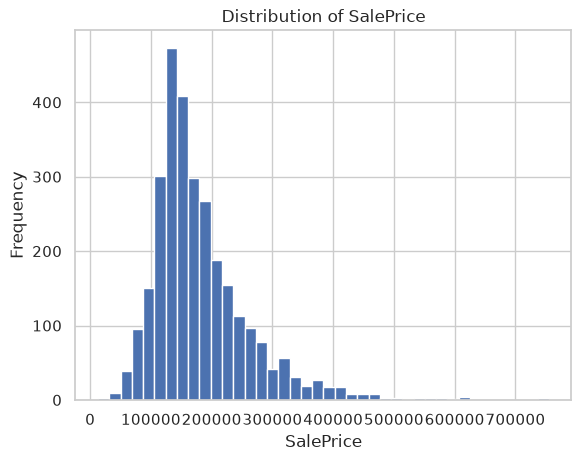

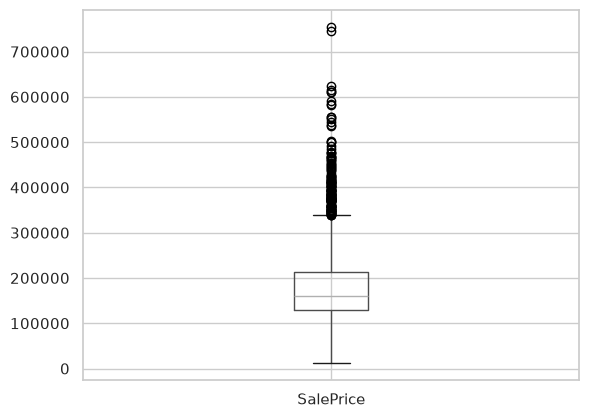

In [17]:
print(df["SalePrice"].describe())
print("skew:", df["SalePrice"].skew())

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
df["SalePrice"].hist(bins=40)
plt.show()



df.boxplot(column="SalePrice")
plt.show()

# SalePrice
The salesprice average is about 180k but is skewed towards the higher range.

Gr Liv Area skew: 1.2741097164955077
count    2930.000000
mean     1499.690444
std       505.508887
min       334.000000
25%      1126.000000
50%      1442.000000
75%      1742.750000
max      5642.000000
Name: Gr Liv Area, dtype: float64


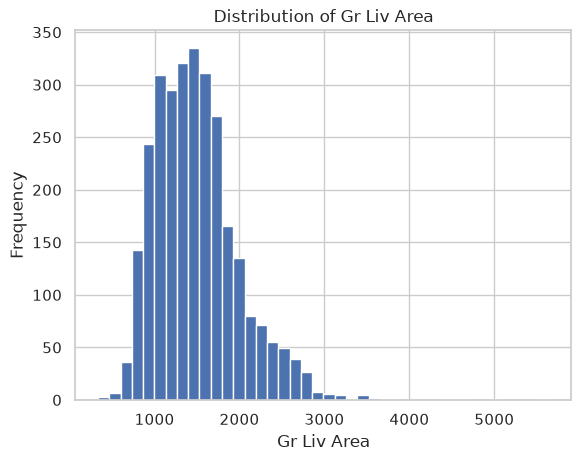

Lot Area skew: 12.820898171092681
count      2930.000000
mean      10147.921843
std        7880.017759
min        1300.000000
25%        7440.250000
50%        9436.500000
75%       11555.250000
max      215245.000000
Name: Lot Area, dtype: float64


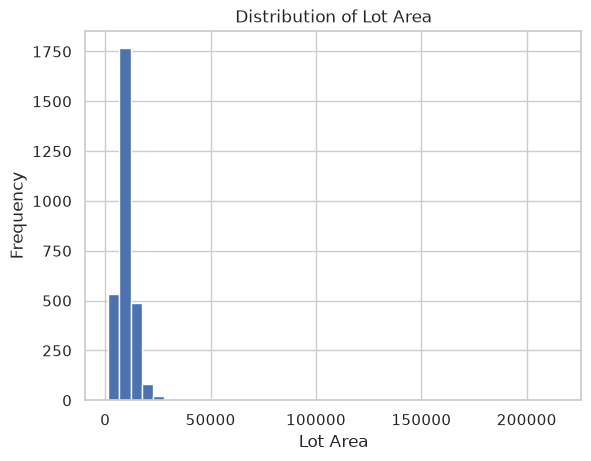

In [22]:
for col in ["Gr Liv Area", "Lot Area"]:
    print(col, "skew:", df[col].skew())
    print(df[col].describe())
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    df[col].hist(bins=40)
    plt.show()

# Living Area / Lot Size
It can be seen that most of the houses fall in the same size of lot, but there is much more variation in the above ground livable area.

no 2nd floor: 0.5726962457337884


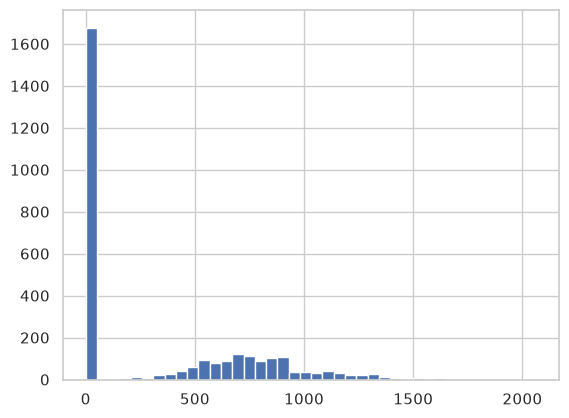

In [ ]:
print("no 2nd floor:", (df["2nd Flr SF"] == 0).mean())
plt.title("Distribution of 2nd Flr SF")
plt.xlabel("2nd Flr SF")
plt.ylabel("Frequency")
df["2nd Flr SF"].hist(bins=40)
plt.show()

# Second Floor
There is a pretty even bell-curve distribution of second floor square footage but the houses with no second floor can be seen as one giant bar on the left.

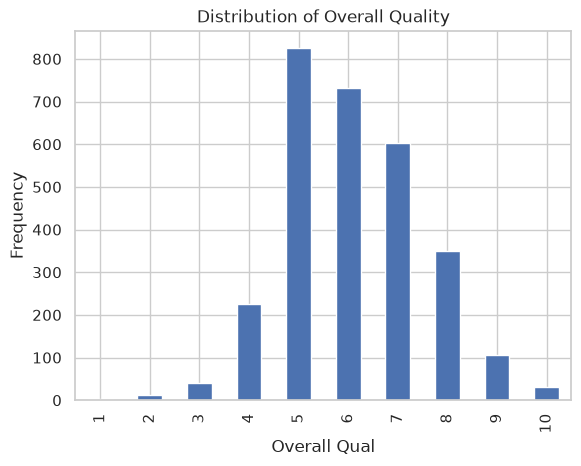

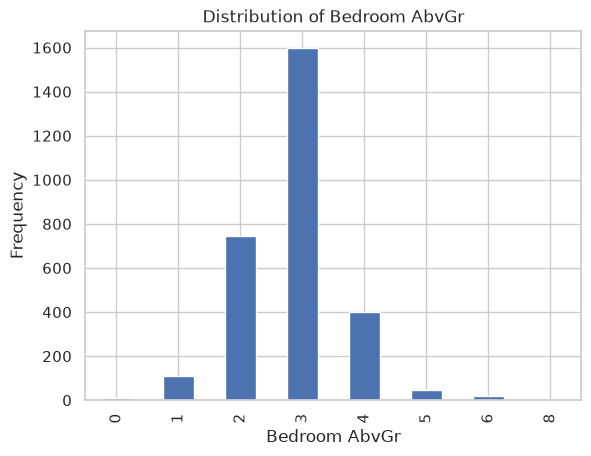

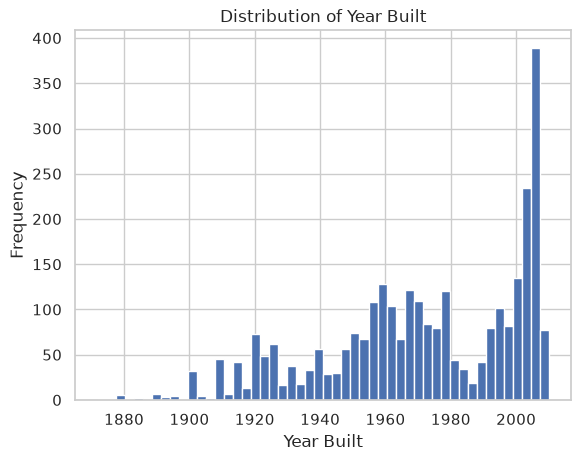

In [24]:
plt.title("Distribution of Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Frequency")
df["Overall Qual"].value_counts().sort_index().plot(kind="bar")
plt.show()

plt.title("Distribution of Bedroom AbvGr")
plt.xlabel("Bedroom AbvGr")
plt.ylabel("Frequency")
df["Bedroom AbvGr"].value_counts().sort_index().plot(kind="bar")
plt.show()

plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Frequency")
df["Year Built"].hist(bins=50)
plt.show()

## Quality
It shows that most of the homes fall in the 5-7 range with a tail scew towards the higher end.

## Bedrooms
It shows that the majority of homes have 3 bedrooms with a fairly normal distribution.

## Year Built
It shows a standard looking distribution of the year homes were built in the 1960s-70s with a large resurgance in the late 90s - 2000s

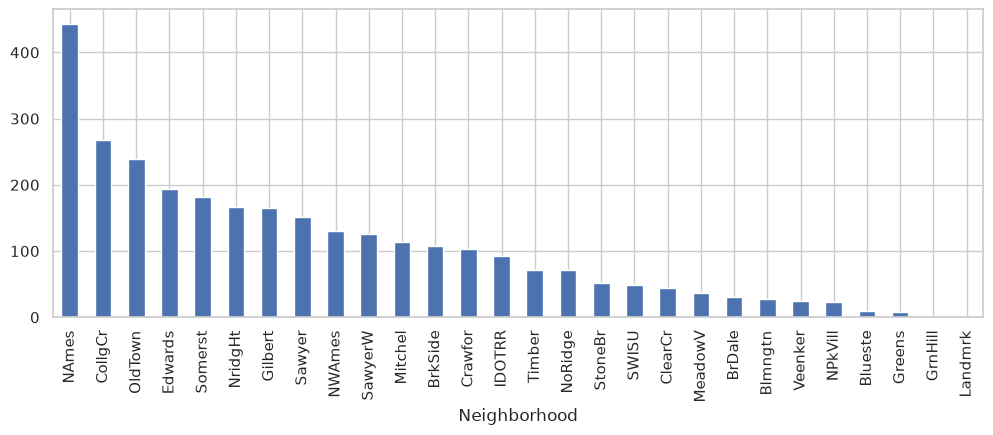

In [25]:
df["Neighborhood"].value_counts().plot(kind="bar", figsize=(12, 4))
plt.show()

# Neighborhood
This shows that North Ames has by far the most houses with each neighborhood after etting smaller and smaller.

Yr Sold
2006    625
2007    694
2008    622
2009    648
2010    341
Name: count, dtype: int64


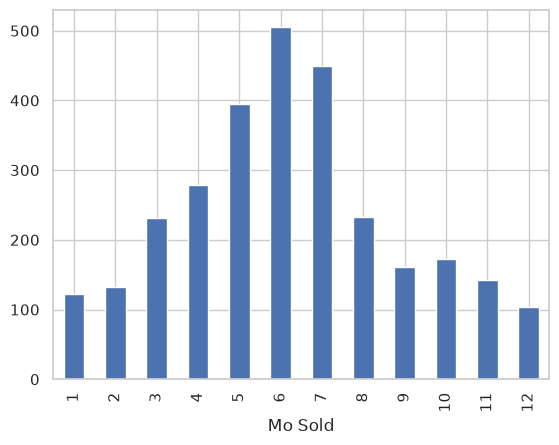

In [26]:
print(df["Yr Sold"].value_counts().sort_index())
df["Mo Sold"].value_counts().sort_index().plot(kind="bar")
plt.show()

# Timing of Sales
This shows that sales peaked in 06-09 and dropped drastically in 2010, possibly due to the housing crisis taking place in those years. (but that is just an assumption, no statistical proof in this dataset)
It also shows that the peak months of house sales are the late spring - early fall months.

         count    median           mean
Yr Sold                                
2006       625  159500.0  181761.648000
2007       694  165125.0  185138.207493
2008       622  161000.0  178841.750804
2009       648  160850.0  181404.567901
2010       341  155000.0  172597.598240


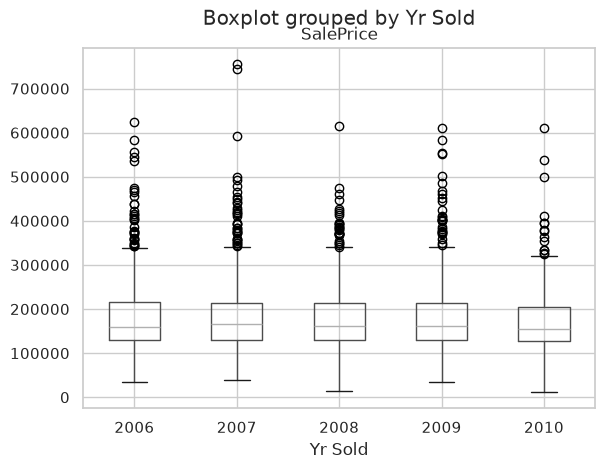

In [39]:
print(df.groupby("Yr Sold")["SalePrice"].agg(["count", "median", "mean"]))

df.boxplot(column="SalePrice", by="Yr Sold")
plt.show()

# Sale Price VS Time
It appears as though the sales price remains relatively the same over 2006-2009 but changes and has less outliers in 2010.

In [40]:
num = df.select_dtypes("number").drop(columns=["Order", "PID"])
num.corr()["SalePrice"].drop("SalePrice").sort_values(key=abs, ascending=False).head(15)

Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Name: SalePrice, dtype: float64

# Price Correlation
There seems to be a very strong relationship between the quality and sales price.
After that there is a fairly strong relationship between price and the following: living area, garage cars/area, square footage for different floors.
The correlations shown above then get weaker as the list goes on.

np.float64(0.7067799209766279)

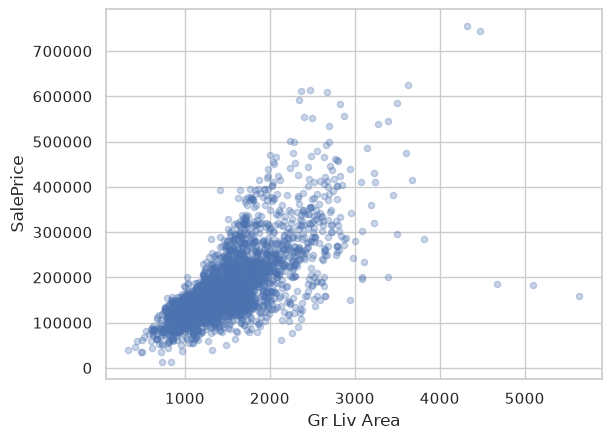

In [41]:
df.plot.scatter(x="Gr Liv Area", y="SalePrice", alpha=0.3)
df["Gr Liv Area"].corr(df["SalePrice"])